#### 순차 데이터 
- 텍스트 데이터(ex: I am a boy.) :  순서가 의미가 있다.
- 시계열 데이터(ex: 1일 10도, 2일 8도)

---
#### 순환 신경망(RNN : Recurrent Neural Network)

I am a boy -> 
- 단어 하나당 3개의 원소로 가진 벡터로 표현
- 샘플이 하나이므로 batch 차원은 1이다.
- 단어의 갯수 : 4개 
(1, 4, 3)

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences # pyright: ignore[reportMissingImports]

1. Tokenizer.   
: 단어를 숫자로 바꾸는 작업
ex:
- I -> 1
- love -> 2
- movie -> 3

2. pad_sequences    
: 문장의 길이가 다르기 때문에 길이를 맞추는 작업.   

3. Embedding    
: 단어를 단순한 숫자가 아니라 의미가 담은 벡터로 바꾸는 작업    


4. SimpleRNN    
: 문장을 앞에서 부터 읽으면서 이전 정보를 기억하는 작업
- I love
- I love this
- I love this movie

In [14]:
# 1. 샘플 데이터 
# sentencs = [
#     "i love this movie",
#     "this film is great",
#     "amazing acting and stroy",
#     "i really liked it",
#     "this was fantastic" # 여기까지 좋은 얘기, 다 소문자로 써줘야 한다 
#     "i hate this movie",
#     "this film is terrible",
#     "bad acting and boring story",
#     "i really disliked it",
#     "this was awful" # 여기까지는 부정
# ]

sentences = [
    'i love this movie',
    'this film is great',
    'amazing acting and story',
    'i really liked it',
    'this was fantastic',
    'i hate this movie',
    'this film is terrible',
    'bad adting and boring story',
    'i really disliked it',
    'this was awful'
]

# 위에 껄 보고 , 긍정 부정을 사람이 나눠줘야 함 
labels = [1,1,1,1,1,0,0,0,0,0]  # 1: POSITIVE, Nagative

In [17]:
# 2. 텍스트를 숫자로 변환
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences) # 위 글자를 학습해서 숫자로 바꾸는 거 _ 학습한 거임
sequences = tokenizer.texts_to_sequences(sentences) # 여기서 바꿔줌 

print("단어 사전 :", tokenizer.word_index)
print("문장 숫자 변환 결과 : ", sequences ) # 이렇게 바꿨는데 [[2, 11, 1, 3], [1, 4, 5, 12], [13, 6, 7, 14], [2, 8, 15, 9], .. 이런식으로 벡터 갯수가 다름

단어 사전 : {'this': 1, 'i': 2, 'movie': 3, 'film': 4, 'is': 5, 'and': 6, 'story': 7, 'really': 8, 'it': 9, 'was': 10, 'love': 11, 'great': 12, 'amazing': 13, 'acting': 14, 'liked': 15, 'fantastic': 16, 'hate': 17, 'terrible': 18, 'bad': 19, 'adting': 20, 'boring': 21, 'disliked': 22, 'awful': 23}
문장 숫자 변환 결과 :  [[2, 11, 1, 3], [1, 4, 5, 12], [13, 14, 6, 7], [2, 8, 15, 9], [1, 10, 16], [2, 17, 1, 3], [1, 4, 5, 18], [19, 20, 6, 21, 7], [2, 8, 22, 9], [1, 10, 23]]


In [18]:
# 3. 길이를 맞춤
max_len = max(len(seq) for seq in sequences) # 시퀀스에서 최대 길이 찾아오기
X = pad_sequences(sequences, maxlen= max_len, padding='post')
y = np.array(labels)

print("패딩 결과")
print(X)
print("입력 shqpe:", X.shape)

패딩 결과
[[ 2 11  1  3  0]
 [ 1  4  5 12  0]
 [13 14  6  7  0]
 [ 2  8 15  9  0]
 [ 1 10 16  0  0]
 [ 2 17  1  3  0]
 [ 1  4  5 18  0]
 [19 20  6 21  7]
 [ 2  8 22  9  0]
 [ 1 10 23  0  0]]
입력 shqpe: (10, 5)


In [21]:
# 4. 모델 생성
vocab_size = len(tokenizer.word_index) + 1 # 단어갯수

model = Sequential(
    [
        Input(shape=(max_len,)),  # 입력 => Feature 갯수
        Embedding(input_dim=vocab_size, output_dim=8), 
        SimpleRNN(16),
        Dense(1, activation='sigmoid') # 트루만 맞추고 나머지는 false 하면 되니까 1임, 
    ]
)

model.compile(loss='binary_crossentropy',optimizer= 'adam',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 8)           │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609 (2.38 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# 5. 학습
history = model.fit(X, y, epochs=30, batch_size=2)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5000 - loss: 0.7037  
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6000 - loss: 0.6966 
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6000 - loss: 0.6903 
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6000 - loss: 0.6856     
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.6800 
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.6744 
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7000 - loss: 0.6692 
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8000 - loss: 0.6620 
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8000 - loss: 0.6551 
Epoch 10/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8000 - loss: 0.6479 
Epoch 11/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9000 - loss: 0.6393 
Epoch 12/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.62

In [23]:
# 6. 예측
test_sentences = [
    'i love it',
    'this was bad',
    'amazing movie',
    'terrible story'
]

# 똑같이 만들어주고 예측해야 함

test_seq = tokenizer.texts_to_sequences(test_sentences)
test_pad = pad_sequences(test_seq, maxlen=max_len, padding='post')

preds = model.predict(test_pad)

for sentence, pred in zip(test_sentences, preds):
    print(f"문장 : {sentence} -> 긍정확률 {pred[0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
문장 : i love it -> 긍정확률 0.9369
문장 : this was bad -> 긍정확률 0.6237
문장 : amazing movie -> 긍정확률 0.8826
문장 : terrible story -> 긍정확률 0.1242


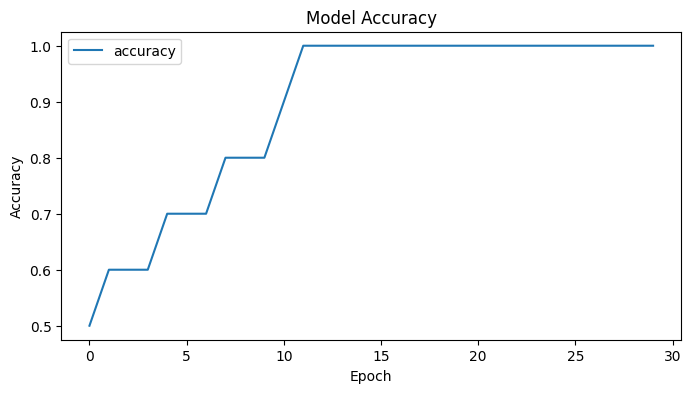

In [24]:
# 6. 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label= 'accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel('Accuracy')
plt.legend()
plt.show()

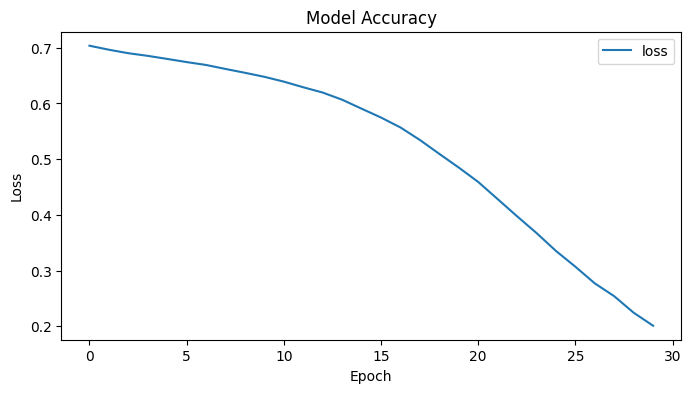

In [25]:
# 손실 그래프
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label= 'loss')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel('Loss')
plt.legend()
plt.show()

In [26]:
# 모델 평가
loss, accuracy = model.evaluate(X, y)
print(f"훈련데이터의 손실 : {loss:.4f}, 정확도 : {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 1.0000 - loss: 0.1853
훈련데이터의 손실 : 0.1853, 정확도 : 1.0000


In [ ]:
# 모델 저장하기
model.save("../Data/rnn_sentiment_model.keras")

In [ ]:
# # 모델 불러오기 (Fast Api)
# from tensorflow.keras.models import load_model
# loaded_model = load_model("../Data/rnn_sentiment_model.keras")

In [32]:
# 모델 불러오기 
from tensorflow.keras.models import load_model
loaded_model = load_model('../Data/rnn_sentiment_model.keras')

In [33]:
# # 불러온 모델로 예측하기
# test_sentence = ['i love movie']
# test_seq = tokenizer.texts_to_sequences(test_sentence)
# test_pad = pad_sequences(test_seq, maxlen= max_len, padding='post')

# pred = loaded_model.predict(test_pad)[0][0]
# print(f"입력문장 : {test_sentence[0]}")
# print(f"긍정확률 : {pred:.4f}")
# print("예측 결과: 긍정" if pred >= 0.5 else "예측 결과: 부정")

# 불러온 모델로 예측하기 
test_sentence = ['i love movie']
test_seq = tokenizer.texts_to_sequences(test_sentence)
test_pad = pad_sequences(test_seq,maxlen=max_len,padding='post')

pred = loaded_model.predict(test_pad)[0][0]
print(f"입력문장 : {test_sentence[0]}")
print(f"긍정확률{pred :.4f}")
print("예측결과 :긍정 " if pred >= 0.5 else "예측결과: 부정")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
입력문장 : i love movie
긍정확률0.9189
예측결과 :긍정 


In [34]:
pred

np.float32(0.91893995)